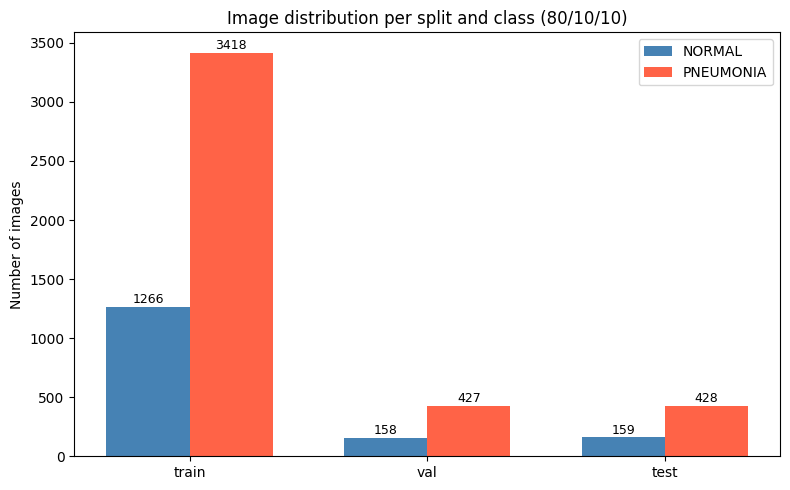

In [1]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

BASE = "../billeder/chest_xray"
classes = ["NORMAL", "PNEUMONIA"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

# Load all image filenames per class
all_files = {}
for cls in classes:
    path = os.path.join(BASE, cls)
    files = [f for f in os.listdir(path) if os.path.splitext(f)[1].lower() in IMAGE_EXTS]
    random.seed(42)
    random.shuffle(files)
    all_files[cls] = files

# 80/10/10 split
splits_data = {}
for cls in classes:
    files = all_files[cls]
    n = len(files)
    n_train = int(n * 0.8)
    n_val   = int(n * 0.1)
    splits_data.setdefault("train", {})[cls] = files[:n_train]
    splits_data.setdefault("val",   {})[cls] = files[n_train:n_train + n_val]
    splits_data.setdefault("test",  {})[cls] = files[n_train + n_val:]

splits = ["train", "val", "test"]

# Count per split and class
counts = {split: {cls: len(splits_data[split][cls]) for cls in classes} for split in splits}

# Bar chart
x = np.arange(len(splits))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, [counts[s]["NORMAL"]    for s in splits], width, label="NORMAL",    color="steelblue")
bars2 = ax.bar(x + width/2, [counts[s]["PNEUMONIA"] for s in splits], width, label="PNEUMONIA", color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel("Number of images")
ax.set_title("Image distribution per split and class (80/10/10)")
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

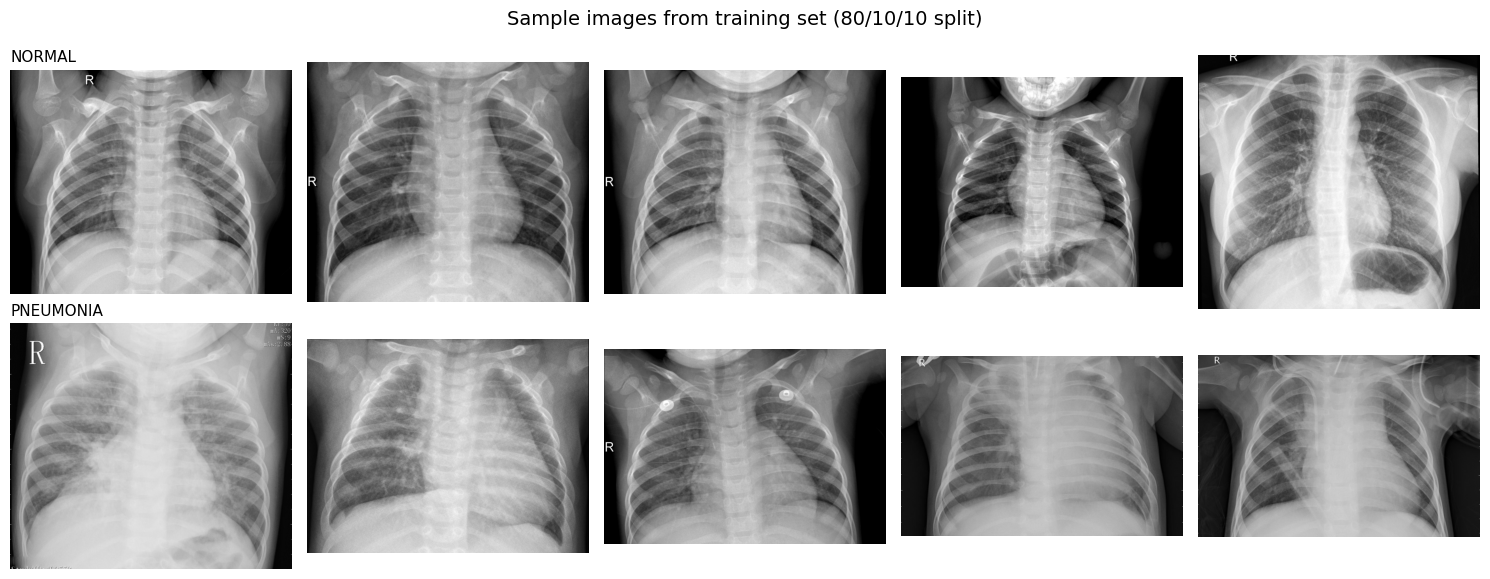

In [8]:
# Show sample images from the training split
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample images from training set (80/10/10 split)", fontsize=14)

for row, cls in enumerate(classes):
    base_path = os.path.join(BASE, cls)
    files = splits_data["train"][cls][:5]
    for col, fname in enumerate(files):
        img = mpimg.imread(os.path.join(base_path, fname))
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(cls, fontsize=11, loc="left")

plt.tight_layout()
plt.show()